In [1]:
import pandas as pd
import numpy as np
import re

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedKFold

import os
import joblib
import json
import copy

# Reading data

In [2]:
# Added parsing of dates afterwards as I realized that dates were stored as objects
raw_data = pd.read_csv("data/bmw_pricing.csv", sep = ",", parse_dates = ["registration_date", "sold_at"])
raw_data

,maker_key,model_key,mileage,engine_power,registration_date,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price,sold_at
0,BMW,118,140411,100,2012-02-01,diesel,black,convertible,True,True,False,False,True,True,True,False,11300,2018-01-01
1,BMW,M4,13929,317,2016-04-01,petrol,grey,convertible,True,True,False,False,False,True,True,True,69700,2018-02-01
2,BMW,320,183297,120,2012-04-01,diesel,white,convertible,False,False,False,False,True,False,True,False,10200,2018-02-01
3,BMW,420,128035,135,2014-07-01,diesel,red,convertible,True,True,False,False,True,True,True,True,25100,2018-02-01
4,BMW,425,97097,160,2014-12-01,diesel,silver,convertible,True,True,False,False,False,True,True,True,33400,2018-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,BMW,218 Gran Tourer,39743,110,2015-10-01,diesel,black,van,False,True,False,False,False,False,True,False,14600,2018-08-01
4839,BMW,218 Active Tourer,49832,100,2015-06-01,diesel,grey,van,False,True,False,False,False,False,True,True,17500,2018-08-01
4840,BMW,218 Gran Tourer,19633,110,2015-10-01,diesel,grey,van,False,True,False,False,False,False,True,True,17000,2018-09-01
4841,BMW,218 Active Tourer,27920,110,2016-04-01,diesel,brown,van,True,True,False,False,False,False,True,True,22700,2018-09-01


In [3]:
# Reduction of Variance Inflation Factor
def reduce_multicollinearity(df, vif_thresh=5.0):
    # Select numeric and bool columns
    X = df.select_dtypes(include=["number", "bool"]).copy()
    # Convert bools to integers
    X = X.apply(lambda col: col.astype(int) if col.dtype == bool else col)
    
    # Drop constant columns
    X = X.loc[:, X.nunique() > 1]
    
    while True:
        # Add constant for VIF calculation
        X_const = sm.add_constant(X, has_constant='add')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data['feature'] = X_const.columns
        vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
        
        # Exclude constant term from dropping
        vif_data = vif_data[vif_data['feature'] != 'const']
        
        max_vif = vif_data['VIF'].max()
        if max_vif <= vif_thresh:
            break
        
        # Drop feature with highest VIF
        drop_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        print(f"Dropping '{drop_feature}' with VIF={max_vif:.2f}")
        X = X.drop(columns=[drop_feature])
        df = df.drop(columns=[drop_feature])
    
    return df

def prepare_data(df, model_key_grouped = True, vif_thresh = None):
    # Filtering data
    df = df.loc[:, df.nunique() > 1]
    df["age"] = (df["sold_at"] - df["registration_date"]).dt.days / 365.25
    df["sold_at"] = (df["sold_at"] - df["sold_at"].min()).dt.days / 365.25
    # Logarithm as it was graphically visible that it would might have an impact
    df["age"] = np.log1p(df["age"])
    df = df.drop(columns=["registration_date"])
        
    col_object = df.select_dtypes(include="string").columns
    col_object = [col for col in col_object if col != "model_key"]
    # Getting dummies
    df = pd.get_dummies(df, columns = col_object, drop_first = True)
    
    if model_key_grouped:

        def is_series(n):
            return lambda x: bool(re.match(rf"[A-Za-z\s]*({str(n)}\d*)", str(x)))

        # Dictionary with all series
        model_key_groups = {
            **{f"Series_{i}": is_series(i) for i in range(1, 8)},
            # Special series
            "i_Series": lambda x: str(x).startswith("i"),
            "M_Series": lambda x: str(x).startswith("M"),
            "Z_Series": lambda x: str(x).startswith("Z"),
            # Special Variants
            "Gran_Turismo": lambda x: "Gran Turismo" in str(x),
            "Gran_Coupé": lambda x: "Gran Coupé" in str(x),
            "Active_Tourer": lambda x: "Active Tourer" in str(x)
        }

        # Apply series
        for group_name, rule in model_key_groups.items():
            df[group_name] = df["model_key"].apply(lambda x: rule(x))
            
    # Drop model_key column
    df.drop(columns = ["model_key"], inplace = True)
    # Splitting target variabe from input
    X = df.loc[:, df.columns != "price"]
    Y = df.loc[:, ["price"]]
    
    if vif_thresh is not None:
        X = reduce_multicollinearity(X, vif_thresh)
        
        
    return X, Y

# Statistical Analysis

In [4]:
X, Y = prepare_data(raw_data, model_key_grouped = True, vif_thresh = 5.0)

X

Dropping 'Series_3' with VIF=1639.08
Dropping 'car_type_estate' with VIF=31.61
Dropping 'paint_color_black' with VIF=27.68


,mileage,engine_power,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,Series_4,Series_5,Series_6,Series_7,i_Series,M_Series,Z_Series,Gran_Turismo,Gran_Coupé,Active_Tourer
0,140411,100,True,True,False,False,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,13929,317,True,True,False,False,False,True,True,True,...,True,False,False,False,False,True,False,False,False,False
2,183297,120,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,128035,135,True,True,False,False,True,True,True,True,...,True,False,False,False,False,False,False,False,False,False
4,97097,160,True,True,False,False,False,True,True,True,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,39743,110,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4839,49832,100,False,True,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,True
4840,19633,110,False,True,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4841,27920,110,True,True,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,True


In [5]:
# columns = X.columns
columns = ["feature_1", "feature_2"]
for col in columns:
    print(X[col].value_counts())

feature_1
True     2662
False    2181
Name: count, dtype: int64
feature_2
True     3839
False    1004
Name: count, dtype: int64


In [6]:
Y

,price
0,11300
1,69700
2,10200
3,25100
4,33400
...,...
4838,14600
4839,17500
4840,17000
4841,22700


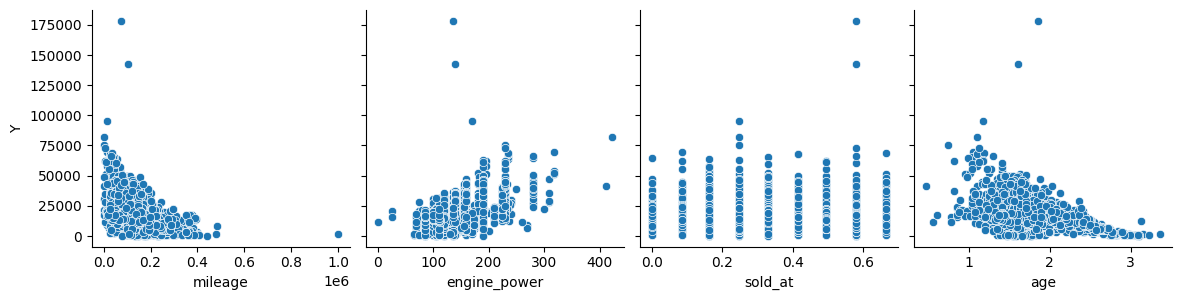

In [7]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if X[col].nunique() > 2]
plot_df = X[numeric_cols].copy()
plot_df["Y"] = Y

# Graphical representation
sns.pairplot(plot_df, y_vars="Y", x_vars=numeric_cols, height=3)
plt.show()

In [8]:
def multiple_regression(X, Y, alpha = 0.05):
    X_model = sm.add_constant(X)

    while True:
        model = sm.OLS(Y, X_model)
        result = model.fit()

        # p-Values without constant
        p_values = result.pvalues.drop("const")

        pval_max = p_values.max()

        if pval_max <= alpha:
            break

        # Highest p-value
        var_to_drop = p_values.idxmax()

        print(
            f"Remove '{var_to_drop}' "
            f"(p-value = {p_values[var_to_drop]:.4f})"
        )

        X_model = X_model.drop(columns=var_to_drop)

    # Final model
    print("\nFinal Model:")
    print(result.summary())

    return X_model, result

X_model, model = multiple_regression(X.astype(float), Y.astype(float), alpha = 0.05)

Remove 'feature_2' (p-value = 0.9394)
Remove 'Gran_Turismo' (p-value = 0.9087)
Remove 'Series_2' (p-value = 0.6795)
Remove 'paint_color_orange' (p-value = 0.6021)
Remove 'fuel_hybrid_petrol' (p-value = 0.5838)
Remove 'paint_color_brown' (p-value = 0.5195)
Remove 'paint_color_grey' (p-value = 0.6089)
Remove 'paint_color_white' (p-value = 0.6564)
Remove 'paint_color_red' (p-value = 0.2865)
Remove 'Active_Tourer' (p-value = 0.2559)
Remove 'Z_Series' (p-value = 0.1432)
Remove 'paint_color_green' (p-value = 0.1372)
Remove 'paint_color_blue' (p-value = 0.1198)
Remove 'paint_color_silver' (p-value = 0.1403)
Remove 'fuel_petrol' (p-value = 0.0752)
Remove 'Gran_Coupé' (p-value = 0.0500)

Final Model:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:          

In [9]:
# Check for reason of high condition number
def condition_number_scaled(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # add constant like in statsmodels
    X_scaled = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])

    return np.linalg.cond(X_scaled)
# High condition number due to scaling
print("Condition Number (scaled):", condition_number_scaled(X))

Condition Number (scaled): 5.051563761978814


In [10]:
Y_pred = model.predict(X_model).clip(lower = 4000)

print(f"Min: {Y_pred.min()}, Max: {Y_pred.max()}")

# Measure performance
def r2(Y, Y_pred):
    r2_val = r2_score(Y, Y_pred)
    print(f"R^2: {r2_val:.3f}")
    return r2_val

r2(Y, Y_pred)

Min: 4000.0, Max: 60095.74439001811
R^2: 0.740


0.7395094803187291

# Machine Learning

In [11]:
X, Y = prepare_data(raw_data, model_key_grouped = True, vif_thresh = 5.0)
X = X.astype(float)
Y = Y.values.ravel()

Dropping 'Series_3' with VIF=1639.08
Dropping 'car_type_estate' with VIF=31.61
Dropping 'paint_color_black' with VIF=27.68


In [12]:
# Initialization
seed = 42

train_size = 0.7
val_test_ratio = 0.5
# Preparation of mldata
def prepare_ml_dl_data(X, Y, train_size, val_test_ratio, seed):
    X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, train_size = train_size, random_state = seed)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, train_size = val_test_ratio, random_state = seed)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    
    return scaler, X_train, X_val, Y_train, Y_val, X_test, Y_test

scaler, X_train, X_val, Y_train, Y_val, X_test, Y_test = prepare_ml_dl_data(X, Y, train_size, val_test_ratio, seed)

In [13]:
# Extracting current version_number
def get_next_version():
    if not os.path.exists(log):
        return 1
    df = pd.read_csv(log)
    if "version" not in df.columns or df.empty:
        return 1
    return int(df["version"].max()) + 1

def model_test(model, scaler, X_train, Y_train, X_val, Y_val, log):
    # retrieve version
    version = get_next_version()
    model_name = model.__class__.__name__
    scaler_name = scaler.__class__.__name__
    model_file = f"model_v{version}.pkl"
    scaler_file = f"scaler_v{version}.pkl"
    model_path = os.path.join("models", model_file)
    scaler_path = os.path.join("models", scaler_file)
    
    # training
    model.fit(X_train, Y_train)

    # validation
    Y_pred = model.predict(X_val)
    r2_val = r2_score(Y_val, Y_pred)

    print(f"{model_name} | v{version} | Validation R²: {r2_val:.4f}")

    # saving
    joblib.dump(model, model_path)
    joblib.dump(scaler, scaler_path)

    # saving parameters
    params_json = json.dumps(model.get_params(), ensure_ascii = False)

    # Update log
    log_entry = pd.DataFrame([{
        "version": version,
        "model": model_name,
        "scaler": scaler_name,
        "r2_val": r2_val,
        "params": params_json,
    }])
    # Enter log
    if os.path.exists(log):
        log_df = pd.read_csv(log)
        log_df = pd.concat([log_df, log_entry], ignore_index = True)
    else:
        log_df = log_entry

    log_df.to_csv(log, index = False)

    # save best model
    if r2_val >= log_df["r2_val"].max():
        joblib.dump(model, "best_model.pkl")
        joblib.dump(scaler, "best_scaler.pkl")
        print("Best model updated")
    # return model
    return {
        "version": version,
        "model": model,
        "scaler": scaler,
        "r2_val": r2_val,
        "params": model.get_params()
    }

In [14]:
log = "model_log.csv"

os.makedirs("models", exist_ok = True)

In [15]:
# model_test(LinearRegression(), X_train, Y_train, X_val, Y_val, log)
# model_test(LogisticRegression(max_iter = 200, random_state = seed), X_train, Y_train, X_val, Y_val, log)
# model_test(RandomForestRegressor(random_state = seed), X_train, Y_train, X_val, Y_val, log)

model_test(XGBRegressor(
    n_estimators = 2500,
    max_depth = 3, 
    max_leaves = 3,
    learning_rate = 0.06,
    tree_method = "auto",
    min_child_weight = 3,
    subsample = 0.8,
    sampling_method = "gradient_based",
    colsample_bytree = 0.8,
    colsample_bylevel = 0.8,
    reg_alpha = 0.5,
    reg_lambda = 3.0,
    random_state = seed,
    device = "gpu"),
           scaler, X_train, Y_train, X_val, Y_val, log)

C:\Users\seidl\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:06:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBRegressor | v1 | Validation R²: 0.8207
Best model updated


{'version': 1,
 'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None, colsample_bytree=0.8,
              device='gpu', early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=3, min_child_weight=3,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=2500, n_jobs=None, num_parallel_tree=None, ...),
 'scaler': StandardScaler(),
 'r2_val': 0.820729672908783,
 'params': {'objective': 'reg:squarederror',
  'base_score': None,
  'booster': None,
  'callbacks': None,
  'colsample_bylevel': 0.8,
  'colsample_bynode': None,
  'colsample_byt

In [16]:
# Combine training and validation sets
X_all = np.vstack([X_train, X_val])
Y_all = np.concatenate([Y_train, Y_val])

# n-fold cross-validation
n_splits = 5
kf = KFold(n_splits = n_splits, shuffle = True, random_state = seed)
# kf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = seed)
# kf = RepeatedKFold(n_splits = n_splits, n_repeats = 3, random_state=seed)

fold = 0
for train_index, val_index in kf.split(X_all, Y_all):
    fold += 1
    print(f"Training fold {fold}/{n_splits}...")
    
    # Split combined dataset for this fold
    X_tr, X_val_fold = X_all[train_index], X_all[val_index]
    Y_tr, Y_val_fold = Y_all[train_index], Y_all[val_index]
    
    # Model
    model = XGBRegressor(
        n_estimators=2400,
        max_depth=3, 
        max_leaves=3,
        learning_rate=0.044,
        tree_method="auto",
        min_child_weight=3,
        subsample=0.8,
        sampling_method="gradient_based",
        colsample_bytree=0.8,
        colsample_bylevel=0.8,
        reg_alpha=0.15,
        reg_lambda=0.9,
        random_state=seed,
        device="gpu"
    )
    
    # Evaluation
    model_test(model, scaler, X_tr, Y_tr, X_val_fold, Y_val_fold, log)

Training fold 1/5...
XGBRegressor | v2 | Validation R²: 0.5983
Training fold 2/5...
XGBRegressor | v3 | Validation R²: 0.8745
Best model updated
Training fold 3/5...
XGBRegressor | v4 | Validation R²: 0.8653
Training fold 4/5...
XGBRegressor | v5 | Validation R²: 0.8492
Training fold 5/5...
XGBRegressor | v6 | Validation R²: 0.7569


# Test (Best) Model

In [17]:
# --- Specify the model version ---
def get_model_path(version=None):
    if version is None:
        model_path = "best_model.pkl"
        scaler_path = "best_scaler.pkl"
    else:
        model_path = os.path.join("models", f"model_v{version}.pkl")
        scaler_path = os.path.join("models", f"scaler_v{version}.pkl")

    return model_path, scaler_path

version_to_load = None
model_path, scaler_path = get_model_path(version_to_load)

# --- Load the model ---
if os.path.exists(model_path):
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    if version_to_load is not None:
        print(f"Model v{version_to_load} loaded successfully!")
    else:
        print("Best Model loaded successfully!")
    
# Transform with scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Predictions on test set ---
Y_pred_test = model.predict(X_test_scaled)

# --- Evaluate ---
r2_test = r2_score(Y_test, Y_pred_test)
if version_to_load is not None:
    print(f"R² for model v{version_to_load} on the test set: {r2_test:.4f}")
else:
    print(f"R² for best model on the test set: {r2_test:.4f}")

# --- Optional: check overfitting with training set ---
Y_pred_train = model.predict(X_train)
r2_train = r2_score(Y_train, Y_pred_train)
print(f"Train R²: {r2_train:.4f} | Test R²: {r2_test:.4f}")

Best Model loaded successfully!
R² for best model on the test set: 0.8769
Train R²: 0.8154 | Test R²: 0.8769


C:\Users\seidl\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Deep Learning

In [18]:
X, Y = prepare_data(raw_data, model_key_grouped = True, vif_thresh = 5.0)
Y = Y.values.ravel()

Dropping 'Series_3' with VIF=1639.08
Dropping 'car_type_estate' with VIF=31.61
Dropping 'paint_color_black' with VIF=27.68


In [19]:
# Initialization
seed = 42

train_size = 0.7
val_test_ratio = 0.5
# Preparation of mldata
scaler, X_train, X_val, Y_train, Y_val, X_test, Y_test = prepare_ml_dl_data(X, Y, train_size, val_test_ratio, seed)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Combine X_train and X_val for k-fold
X_all = np.vstack([X_train, X_val])
Y_all = np.hstack([Y_train, Y_val])
X_all = torch.tensor(X_all, dtype=torch.float32, device=device)
Y_all = torch.tensor(Y_all, dtype=torch.float32, device=device)

In [21]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [22]:
k = 5
kf = KFold(n_splits = k, shuffle = True, random_state = 42)

best_fold_val_loss = float("inf")
best_fold_model_wts = None
best_fold_epoch = -1
best_y_scaler = None
best_X_val_fold = None
best_Y_val_fold = None
best_y_val_pred = None
best_val_pred = torch.zeros_like(Y_all)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
    print(f"\nFold {fold + 1}")
    
    X_train = X_all[train_idx].to(device)
    Y_train = Y_all[train_idx].to(device)
    X_val = X_all[val_idx].to(device)
    Y_val = Y_all[val_idx].to(device)
    
    # Scale Y
    y_scaler = StandardScaler()
    Y_train = torch.tensor(
        y_scaler.fit_transform(Y_train.cpu().numpy().reshape(-1, 1)),
        dtype=torch.float32,
        device=device
    )
    Y_val = torch.tensor(
        y_scaler.transform(Y_val.cpu().numpy().reshape(-1, 1)),
        dtype=torch.float32,
        device=device
    )
    
    # Initialize model
    input_dim = X_train.shape[1]
    model = RegressionModel(input_dim).to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=1e-5)
    
    # Training parameters
    epochs = 10000
    early_stop_patience = 500
    
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch = -1
    epochs_no_improve = 0
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        y_pred = model(X_train)
        train_loss = criterion(y_pred, Y_train)
        
        train_loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step()
        scheduler.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, Y_val)
        
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_pred = val_pred
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 100 == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch:4d} | "
                f"Train MSE: {train_loss.item():.4f} | "
                f"Val MSE: {val_loss.item():.4f} | "
                f"LR: {lr:.2e}"
            )

    print("Best Val MSE:", best_val_loss.item())
    print("Best Val Epoch:", best_epoch)
    print("Best Val R2:", r2_score(Y_val.cpu().numpy().flatten(), best_val_pred.cpu().numpy().flatten()))
    
    # Save best fold if it's better than previous folds
    if best_val_loss < best_fold_val_loss:
        best_fold_val_loss = best_val_loss
        best_fold_model_wts = copy.deepcopy(best_model_wts)
        best_fold_epoch = best_epoch
        best_y_scaler = copy.deepcopy(y_scaler)
        best_X_val_fold = X_val
        best_Y_val_fold = Y_val

# Load the best model from the best fold
model.load_state_dict(best_fold_model_wts)

# Final validation on the best fold
model.eval()
with torch.no_grad():
    y_val_pred = model(best_X_val_fold)

y_val_pred = y_val_pred.cpu().numpy()
best_Y_val_fold = best_Y_val_fold.cpu().numpy()

print("\nBest Fold Results")
print("Best Val MSE:", best_fold_val_loss.item())
print("Best Val Epoch:", best_fold_epoch)
print("Val R2:", r2_score(best_Y_val_fold, y_val_pred))


Fold 1
Epoch    0 | Train MSE: 1.1221 | Val MSE: 1.2666 | LR: 1.00e-03
Epoch  100 | Train MSE: 0.1611 | Val MSE: 0.5589 | LR: 9.75e-04
Epoch  200 | Train MSE: 0.1184 | Val MSE: 0.5293 | LR: 9.05e-04
Epoch  300 | Train MSE: 0.0922 | Val MSE: 0.5284 | LR: 7.95e-04
Epoch  400 | Train MSE: 0.0828 | Val MSE: 0.5215 | LR: 6.56e-04
Epoch  500 | Train MSE: 0.0781 | Val MSE: 0.5207 | LR: 5.03e-04
Epoch  600 | Train MSE: 0.0690 | Val MSE: 0.5184 | LR: 3.51e-04
Epoch  700 | Train MSE: 0.0674 | Val MSE: 0.5206 | LR: 2.13e-04
Epoch  800 | Train MSE: 0.0662 | Val MSE: 0.5205 | LR: 1.04e-04
Epoch  900 | Train MSE: 0.0655 | Val MSE: 0.5220 | LR: 3.37e-05
Early stopping at epoch 961
Best Val MSE: 0.5142987370491028
Best Val Epoch: 461
Best Val R2: 0.6134655475616455

Fold 2
Epoch    0 | Train MSE: 1.1584 | Val MSE: 0.8394 | LR: 1.00e-03
Epoch  100 | Train MSE: 0.2171 | Val MSE: 0.1209 | LR: 9.75e-04
Epoch  200 | Train MSE: 0.1516 | Val MSE: 0.1013 | LR: 9.05e-04
Epoch  300 | Train MSE: 0.1194 | Val MS

# Summary
## Topics
- Statistical Model
- Machine Learning Model(s)
- Deep Learning Model
## What I took care of:
- Statistical model as baseline model
    - Multiple Regression
        - other options could include choosing after AIC criterion, Polynomial regression, etc.
- Exploration of Machine Learning Model with focus on one of the more modern approaches
    - Usage of scikit-learn to easify the programming part due to limited time available
        - e.g. keras could also be used
    - Advantage (of xgboost) of training being basically for free (trained locally on AMD Ryzen 7940HS and Geforce RTX 4070)
    - Downside of accuracy not being that high
        - could be probably further improved with more finetuning time or more nuanced parameter tuning
## What I learned newly
- Usage of joblib
- Usage of xgboost
## Errors I made
- Forgot to save scaler originally
    - Error was discovered after a good night of sleep (/ break) and questionable results on test set 
## Room for Improvement
(not done due to lack of time and exam on 19.12.2025 in Reinforcement Learning)

- Saving and documenting the whole pipeline (dataset used, columns used, kfold used, time, GPU, Train R^2, Val R^2, etc.)
    - e.g. usage of scikit-learn pipeline and/or well written logging
- Setting it up in a real data pipeline outside of Jupyter Notebook
- Better structure
    - e.g. def function all in one place, etc.
- Usage of more functions and automatized testing
    - e.g. Usage of Optuna for more automatized parameter search
    - e.g. Usage of gridsearch/randomsearch/more advanced optimization strategies
- Input data on gpu (for XGBoost)
- Variable naming (not using same variables)